# Goal
- How the CoRE Stack represents **landscape entities**
- How to **fetch**, **process** and **analyze** CoRE Stackdata from underlying geospatial layers using python
- How to generate useful insights from the data

The CoRE Stack organizes data into **nested landscape entities**

Example:
`Watershed or Tehsil --> Micro-Watersheds (MWS) --> Surface Waterbodies`

Each entitiy contain **spatial geometry** and **thematic attributes** derived from geospatial layers such as --
- Terrain Classes
- Cropping Intensity
- Water Balance
- Drought Frequency
- Seasonal Surface Water Availability
- Drainage/Stream Networks
- Land-use and Land-cover
- Precipitation & Evapotranspiration

The **Entity-Relationship (ER)** diagram can help us visualize this conceptually

![](https://camo.githubusercontent.com/59ed6e28e204fad790f865e271dfa27e548b0d533a7874118ab1c2c91ef864dd/68747470733a2f2f636f72652d737461636b2e6f72672f77702d636f6e74656e742f75706c6f6164732f323032352f31312f7761746572736865645f6572642d312e6a7067)

In [ ]:
from google.colab import userdata
API_KEY = userdata.get('API_KEY')

# CoRE Stack ORM

In [ ]:
from types import NoneType
from typing import Optional, Dict
from datetime import datetime
import json
import numpy as np

class tehsil_data:
    """
    Tehsil/Block administrative unit data class containing location information
    and a collection of microwatersheds and waterbodies within the tehsil.
    """

    def __init__(self, state, district, tehsil):
        # === IDENTIFICATION ===
        self.tehsil_name: str = tehsil
        self.district_name: str = district
        self.state_name: str = state

        # === GEOMETRY ===
        self.geometry: Optional[object] = None

        # === MICROWATERSHEDS ===
        self.microwatersheds: Optional[Dict(str, MWS_data)] = {}

        # === WATERBODIES ===
        self.waterbodies: Optional[Dict(str, waterbody_data)] = {}

In [ ]:
class MWS_data:
    """
    Microwatershed data class combining terrain, cropping intensity,
    drought frequency, and hydrology variables, and waterbodies in the micro-watershed.
    """

    def __init__(self):
        # === IDENTIFICATION ===
        self.uid: str = None

        # === AREA METRICS ===
        self.area_in_ha: Optional[float] = None

        # === TERRAIN CLASSIFICATION ===
        self.plain_area: Optional[float] = None
        self.slopy_area: Optional[float] = None
        self.hill_slope: Optional[float] = None
        self.valley_are: Optional[float] = None
        self.ridge_area: Optional[float] = None
        self.terrainClu: Optional[int] = None

        # === TREE COVER REDUCTION ===
        self.forest_to_barren: Optional[float] = None
        self.forest_to_builtu: Optional[float] = None
        self.forest_to_farm: Optional[float] = None
        self.forest_to_forest: Optional[float] = None
        self.forest_to_scrub: Optional[float] = None

        # === HYDROLOGICAL DATA: PRECIPITATION, RUNOFF, ET ===
        self.hydro_dates_data: Optional[datetime] = None
        self.hydro_rainfall_data: Optional[np.array] = None
        self.hydro_et_data: Optional[np.array] = None
        self.hydro_runoff_data: Optional[np.array] = None
        self.hydro_waterbalance_data: Optional[np.array] = None

        # === SURFACE WATER AREA ===
        self.swb_area_in_ha: Optional[float] = None

        # === SURFACE WATER AREA (Dict[year_range, hectares]) ===
        self.sw_area: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === WATER AVAILABILITY - KHARIF SEASON (Dict[year_range, percent]) ===
        self.sw_k: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === WATER AVAILABILITY - KHARIF & RABI SEASONS (Dict[year_range, percent]) ===
        self.sw_kr: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === WATER AVAILABILITY - ALL SEASONS (Dict[year_range, percent]) ===
        self.sw_krz: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === CROPPING INTENSITY - TOTALS ===
        self.total_cropable_area_ever_hydroyear_2017_2023: Optional[float] = None

        # === CROPPING INTENSITY - ANNUAL (Dict[year, value]) ===
        self.cropping_intensity: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === SINGLE CROPPED AREA (Dict[year, value]) ===
        self.single_cropped_area: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === SINGLE KHARIF CROPPED AREA (Dict[year, value]) ===
        self.single_kharif_cropped_area: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === SINGLE NON-KHARIF CROPPED AREA (Dict[year, value]) ===
        self.single_non_kharif_cropped_area: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === DOUBLE CROPPED AREA (Dict[year, value]) ===
        self.doubly_cropped_area: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === TRIPLE CROPPED AREA (Dict[year, value]) ===
        self.triply_cropped_area: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === DROUGHT CLASSIFICATION (Dict[year, label]) ===
        self.drlb: Dict[str, Optional[str]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        # === DRY SPELL ANALYSIS ===
        self.avg_dryspell: Optional[float] = None
        self.drysp: Dict[str, Optional[int]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        # === DROUGHT WEEKS BY SEVERITY (Dict[year, weeks]) ===
        self.w_no: Dict[str, Optional[int]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        self.w_mld: Dict[str, Optional[int]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        self.w_mod: Dict[str, Optional[int]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        self.w_sev: Dict[str, Optional[int]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        # === TOTAL ANALYSIS WEEKS (Dict[year, weeks]) ===
        self.t_wks: Dict[str, Optional[int]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        # === DROUGHT FREQUENCY BY THRESHOLD (Dict[year, frequency]) ===
        self.frth0: Dict[str, Optional[int]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        self.frth1: Dict[str, Optional[int]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        self.frth2: Dict[str, Optional[int]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        self.frth3: Dict[str, Optional[int]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        # === DROUGHT INTENSITY BY THRESHOLD (Dict[year, intensity]) ===
        self.inth0: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        self.inth1: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        self.inth2: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        self.inth3: Dict[str, Optional[int]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        # === MONSOON ONSET (Dict[year, datetime]) ===
        self.m_ons: Dict[str, Optional[datetime]] = {
            '2017': None, '2018': None, '2019': None,
            '2020': None, '2021': None, '2022': None
        }

        # === RAINFALL, ET, RUNOFFF - AQUIFER ===
        self.weighted_a: Optional[float] = None

        # === RAINFALL, ET, RUNOFF - ANNUAL CHANGE (Dict[year_range, value]) ===
        self.well_depth: Dict[str, Optional[str]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None, '2024': None
        }

        # === WELL DEPTH - MULTI-YEAR NET CHANGE (Dict[year_range, value]) ===
        self.well_depth_net: Dict[str, Optional[float]] = {
            '2017_2022': None, '2018_2023': None, '2019_2024': None, '2020_2025': None
        }

        # === GEOMETRY ===
        self.geometry: Optional[object] = None

        # === WATERBODIES ===
        self.waterbodies: Optional[Dict(str, waterbody_data)] = {}


In [ ]:
class waterbody_data:
    """
    Surface water body data class containing comprehensive waterbody information
    including location, physical characteristics, seasonal availability, and
    management details.
    """

    def __init__(self):
        # === IDENTIFICATION ===
        self.UID: str = None
        self.census_id: Optional[str] = None
        self.MWS_UID: str = None

        # === HYDROLOGICAL CLASSIFICATION ===
        self.basin_name: Optional[str] = None
        self.sub_basin_name: Optional[str] = None

        # === SURFACE WATER AREA (Dict[year_range, hectares]) ===
        self.area: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === WATER AVAILABILITY - KHARIF SEASON (Dict[year_range, percent]) ===
        self.k: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === WATER AVAILABILITY - KHARIF & RABI SEASONS (Dict[year_range, percent]) ===
        self.kr: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === WATER AVAILABILITY - ALL SEASONS (Dict[year_range, percent]) ===
        self.krz: Dict[str, Optional[float]] = {
            '2017': None, '2018': None, '2019': None, '2020': None,
            '2021': None, '2022': None, '2023': None
        }

        # === LOCATION INFORMATION: FILLED FROM WATERBODY CENSUS - CAN BE INCOMPLETE ===
        self.State_Name: Optional[str] = None
        self.District_Name: Optional[str] = None
        self.Block_Tehsil_Name: Optional[str] = None
        self.Village_Name: Optional[str] = None
        self.town_municipalty_name: Optional[str] = None
        self.ward_name: Optional[str] = None
        self.rural_or_urban: Optional[str] = None
        self.latitude_dec: Optional[float] = None
        self.longitude_dec: Optional[float] = None

        # === WATER BODY CHARACTERISTICS: FILLED FROM WATERBODY CENSUS - CAN BE INCOMPLETE ===
        self.water_body_name: Optional[str] = None
        self.water_body_loc_name: Optional[str] = None
        self.ref_water_body_type_id_name: Optional[str] = None
        self.water_body_nature_name: Optional[str] = None
        self.manmade_water_body_type_name: Optional[str] = None
        self.water_body_ownership_name: Optional[str] = None
        self.nature_of_storage: Optional[str] = None

        # === PHYSICAL CHARACTERISTICS: FILLED FROM WATERBODY CENSUS - CAN BE INCOMPLETE ===
        self.water_spread_area_of_water_body: Optional[float] = None
        self.area_ored: Optional[float] = None
        self.max_depth_water_body_fully_filled: Optional[float] = None
        self.storage_capacity_water_body_original: Optional[float] = None
        self.storage_capacity_water_body_present: Optional[float] = None
        self.category_sq_m: Optional[str] = None

        # === STORAGE STATUS:: FILLED FROM WATERBODY CENSUS - CAN BE INCOMPLETE ===
        self.filled_up_storage_name: Optional[str] = None
        self.filled_up_storage_space_name: Optional[str] = None

        # === CONSTRUCTION & ADMINISTRATIVE: FILLED FROM WATERBODY CENSUS - CAN BE INCOMPLETE ===
        self.construcion_year: Optional[float] = None
        self.construction_cost: Optional[float] = None
        self.khasra_number: Optional[str] = None
        self.si_no_of_water_body_within_village_town: Optional[float] = None

        # === USAGE & BENEFICIARIES: FILLED FROM WATERBODY CENSUS - CAN BE INCOMPLETE ===
        self.ref_water_body_in_use_id_name: Optional[str] = None
        self.ref_reason_water_body_in_use_id1_name: Optional[str] = None
        self.reason_water_body_in_use_name2: Optional[str] = None
        self.reason_water_body_in_use_name3: Optional[str] = None
        self.no_people_benefited_by_water_body: Optional[float] = None
        self.no_villages_benefited: Optional[float] = None
        self.no_town_cities_benefited: Optional[float] = None
        self.cca_water_body: Optional[float] = None
        self.ipc_water_body: Optional[float] = None

        # === MANAGEMENT & MAINTENANCE: FILLED FROM WATERBODY CENSUS - CAN BE INCOMPLETE ===
        self.ref_water_body_under_repair_renovation_restoration_id_name: Optional[str] = None
        self.scheme_status_reason_name: Optional[str] = None
        self.scheme_under_revival_is_done: Optional[str] = None
        self.ref_selection_id_dip_sip_exists_name: Optional[str] = None
        self.ref_selection_id_wua_exists_name: Optional[str] = None

        # === ENCROACHMENT: FILLED FROM WATERBODY CENSUS - CAN BE INCOMPLETE ===
        self.ref_selection_id_water_body_encroached_name: Optional[str] = None
        self.ref_selection_id_encroachment_assessed_name: Optional[str] = None

        # === GEOMETRY ===
        self.geometry: Optional[object] = None


In [ ]:
class loading_util:
    @staticmethod
    def ensure_feature_list(geojson):
        """Normalize structure: Accepts Feature or FeatureCollection."""
        if geojson.get("type") == "FeatureCollection":
            return geojson.get("features", [])
        return [geojson]

    #HELPER METHOD
    @staticmethod
    def split_every_second_underscore(s):
        parts = s.split('_')
        if len(parts) > 2:
            return ['_'.join(parts[i:i+2]) for i in range(0, len(parts), 2)]
        else:
            return [s]

    #HELPER METHOD
    @staticmethod
    def load_waterbody_in_mws(obj, waterbody):
        mws_ids = loading_util.split_every_second_underscore(waterbody.MWS_UID)
        for mws_id in mws_ids:
            mws = obj.microwatersheds[mws_id]
            mws.waterbodies[waterbody.UID] = waterbody

    #HELPER METHOD
    @staticmethod
    def load_base_fields(obj, props):
        if props.get("uid") not in obj.microwatersheds.keys():
            obj.microwatersheds[props.get("uid")] = MWS_data()
        mws = obj.microwatersheds[props.get("uid")]
        mws.uid = mws.uid or props.get("uid")
        if "area_in_ha" in props.keys():
            mws.area_in_ha = mws.area_in_ha or props.get("area_in_ha")
        if "geometry" in props.keys():
            mws.geometry = mws.geometry or props.get("geometry")  # Keep if already loaded
        return mws

    #LOAD FROM TERRAIN TEHSIL LAYER
    @staticmethod
    def load_terrain(obj, geojson):
        for feat in loading_util.ensure_feature_list(geojson):
            props = feat.get("properties", {})
            mws = loading_util.load_base_fields(obj, props)
            mws.plain_area = props.get("plain_area")
            mws.slopy_area = props.get("slopy_area")
            mws.hill_slope = props.get("hill_slope")
            mws.valley_are = props.get("valley_are")
            mws.ridge_area = props.get("ridge_area")
            mws.terrainClu = props.get("terrainClu")

    #LOAD FROM CROPPING INTENSITY TEHSIL LAYER
    @staticmethod
    def load_cropping_intensity(obj, geojson):
        for feat in loading_util.ensure_feature_list(geojson):
            props = feat.get("properties", {})
            mws = loading_util.load_base_fields(obj, props)
            for y in mws.cropping_intensity.keys():
                key = f"cropping_intensity_{y}"
                if key in props:
                    mws.cropping_intensity[y] = props[key]
                key = f'single_cropped_area_{y}'
                if key in props:
                    mws.single_cropped_area[y] = props[key]
                key = f'single_kharif_cropped_area_{y}'
                if key in props:
                    mws.single_kharif_cropped_area[y] = props[key]
                key = f'single_non_kharif_cropped_area_{y}'
                if key in props:
                    mws.single_non_kharif_cropped_area[y] = props[key]
                key = f'doubly_cropped_area_{y}'
                if key in props:
                    mws.doubly_cropped_area[y] = props[key]
                key = f'triply_cropped_area_{y}'
                if key in props:
                    mws.triply_cropped_area[y] = props[key]
            mws.total_cropable_area_ever_hydroyear_2017_2023 = props.get("total_cropable_area_ever_hydroyear_2017_2023")

    #LOAD FROM HYDROLOGY TEHSIL LAYER
    @staticmethod
    def load_well_depth(obj, geojson):
        for feat in loading_util.ensure_feature_list(geojson):
            props = feat.get("properties", {})
            mws = loading_util.load_base_fields(obj, props)
            mws.weighted_a = props.get("weighted_a")
            for yr in mws.well_depth.keys():
                yr_range = "_".join([yr, str(int(yr)+1)])
                if yr_range in props:
                    mws.well_depth[yr] = props[yr_range]
            for k in mws.well_depth_net.keys():
                prop_key = f"Net{k.replace('_', '_')}"
                if prop_key in props:
                    mws.well_depth_net[k] = props[prop_key]

    #LOAD FROM DROUGHT TEHSIL LAYER
    @staticmethod
    def load_drought_frequency(obj, geojson):
        for feat in loading_util.ensure_feature_list(geojson):
            props = feat.get("properties", {})
            mws = loading_util.load_base_fields(obj, props)
            mws.avg_dryspell = props.get("avg_dryspell")
            for y in mws.drlb.keys():
                dr = f"drlb_{y}"
                if dr in props:
                    mws.drlb[y] = props[dr]
                ds = f"drysp_{y}"
                if ds in props:
                    mws.drysp[y] = props[ds]
                for severity in ['no', 'mld', 'mod', 'sev']:
                    key = f'w_{severity}_{y}'
                    if key in props:
                        getattr(mws, f'w_{severity}')[y] = props[key]
                key = f't_wks_{y}'
                if key in props:
                    mws.t_wks[y] = props[key]
                for t in ["frth0", "frth1", "frth2", "frth3"]:
                    key = f"{t}_{y}"
                    if key in props:
                        getattr(mws, t)[y] = props[key]
                for t in ["inth0", "inth1", "inth2", "inth3"]:
                    key = f"{t}_{y}"
                    if key in props:
                        getattr(mws, t)[y] = props[key]
                key = f'm_ons_{y}'
                if key in props:
                    mws.m_ons[y] = props[key]

    #LOAD FROM WATERBODY TEHSIL LAYER
    @staticmethod
    def load_waterbodies(obj, geojson):
        for feat in loading_util.ensure_feature_list(geojson):
            props = feat.get("properties", {})
            if props.get("UID") not in obj.waterbodies.keys():
                obj.waterbodies[props.get("UID")] = waterbody_data()
            waterbody = obj.waterbodies[props.get("UID")]
            waterbody.UID = props.get("UID")
            waterbody.census_id = props.get("census_id")
            waterbody.MWS_UID = props.get("MWS_UID")
            loading_util.load_waterbody_in_mws(obj, waterbody)
            waterbody.geometry = feat.get("geometry")
            for yr in waterbody.area.keys():
                src = f"area_{str(int(yr))[2:]}-{str(int(yr)+1)[2:]}"
                if src in props:
                    waterbody.area[yr] = props[src]
            for prefix, target in [("k", waterbody.k), ("kr", waterbody.kr), ("krz", waterbody.krz)]:
                for yr in target.keys():
                    src = f"{prefix}_{str(int(yr))[2:]}-{str(int(yr)+1)[2:]}"
                    if src in props:
                        target[yr] = props[src]

    #LOAD FROM TEHSIL API DATA
    @staticmethod
    def load_from_api_payload(obj, api_response, mws_params):
        for mws_param in mws_params:
            if mws_param == "terrain":
                for data in api_response.get(mws_param, []):
                    data = dict(data)
                    mws = loading_util.load_base_fields(obj, data)
                    mws.area_in_ha = data["area_in_ha"]
                    mws.plain_area = data["plain_area_percent"]
                    mws.slopy_area = data["slopy_area_percent"]
                    mws.hill_slope = data["hill_slope_area_percent"]
                    mws.valley_are = data["valley_area_percent"]
                    mws.ridge_area = data["ridge_area_percent"]
                    mws.terrainClu = data["terrain_cluster_id"]
            elif mws_param == "change_detection_deforestation":
                for data in api_response.get(mws_param, []):
                    data = dict(data)
                    mws = loading_util.load_base_fields(obj, data)
                    mws.area_in_ha = data["area_in_ha"]
                    mws.forest_to_barren = data["forest_to_barren_area_in_ha"]
                    mws.forest_to_builtu = data["forest_to_built_up_area_in_ha"]
                    mws.forest_to_farm   = data["forest_to_farm_area_in_ha"]
                    mws.forest_to_forest = data["forest_to_forest_area_in_ha"]
                    mws.forest_to_scrub = data["forest_to_scrub_land_area_in_ha"]
            elif mws_param == "surfaceWaterBodies_annual":
                for data in api_response.get(mws_param, []):
                    data = dict(data)
                    mws = loading_util.load_base_fields(obj, data)

                    mws.swb_area_in_ha = data['total_swb_area_in_ha']
                    # Process year-range keys from API response
                    year_data = {}
                    for key, value in data.items():
                        if key.startswith('total_area_in_ha_') or key.startswith('kharif_area_in_ha_') or \
                            key.startswith('rabi_area_in_ha_') or key.startswith('zaid_area_in_ha_'):
                            # Extract year range (e.g., "2017-2018" from "total_area_in_ha_2017-2018")
                            year_range = key.split('_')[-1]  # Get "2017-2018"
                            start_year = year_range.split('-')[0]  # Get "2017"

                            if start_year not in year_data:
                                year_data[start_year] = {}

                            if key.startswith('total_area_in_ha_'):
                                year_data[start_year]['total'] = float(value)
                            elif key.startswith('kharif_area_in_ha_'):
                                year_data[start_year]['kharif'] = float(value)
                            elif key.startswith('rabi_area_in_ha_'):
                                year_data[start_year]['rabi'] = float(value)
                            elif key.startswith('zaid_area_in_ha_'):
                                year_data[start_year]['zaid'] = float(value)

                    # Fill sw_area, sw_k, sw_kr, sw_krz dictionaries
                    for year, areas in year_data.items():
                        if year in mws.sw_area.keys():
                            # sw_area: total area
                            if 'total' in areas:
                                mws.sw_area[year] = areas['total']

                            # Calculate percentages
                            total = areas.get('total', 0)
                            if total > 0:
                                # sw_k: kharif only (percentage)
                                if 'kharif' in areas:
                                    mws.sw_k[year] = (areas['kharif'] / total) * 100

                                # sw_kr: kharif + rabi (percentage)
                                if 'rabi' in areas:
                                    mws.sw_kr[year] = (areas['rabi'] / total) * 100

                                # sw_krz: all seasons kharif + rabi + zaid (percentage)
                                if 'zaid' in areas:
                                    mws.sw_krz[year] = (areas['zaid'] / total) * 100

    #LOAD FROM MWS API DATA
    @staticmethod
    def load_hydro_data_from_api_payload(obj, hydrological_data):
        obj.hydro_dates_data = [datetime.strptime(item['date'], '%Y-%m-%d') for item in hydrological_data]
        obj.hydro_rainfall_data = np.array([item['precipitation'] for item in hydrological_data])
        obj.hydro_et_data = np.array([item['et'] for item in hydrological_data])
        obj.hydro_runoff_data = np.array([item['runoff'] for item in hydrological_data])

        # Calculate water balance
        obj.hydro_waterbalance_data = obj.hydro_rainfall_data - obj.hydro_et_data - obj.hydro_runoff_data

# CoRE Stack Layer Load

In [ ]:
import requests
import json
from collections import defaultdict
# from core_stack_orm import *
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast
import pandas as pd

def parse_layers(layer_list):
    """
    Convert JSON output of a list of layers into a clean structure,
    grouped by layer_name. Handles duplicates by appending.
    """
    parsed = defaultdict(list)

    for layer in layer_list:
        name = layer.get("layer_name", "Unknown")
        entry = {
            "type": layer.get("layer_type"),
            "url": layer.get("layer_url"),
            "version": layer.get("layer_version"),
            "style": layer.get("style_url"),
            "gee_asset": layer.get("gee_asset_path"),
        }
        parsed[name].append(entry)

    return dict(parsed)

In [ ]:
def download_layer(url, output_file):
    # Send an HTTP GET request to the URL
    # verify=False disables SSL certificate verification (only use this if absolutely necessary)
    response = requests.get(url, verify=False)

    # Check if the request was successful (HTTP status code 200 means OK)
    if response.status_code == 200:
        # Open a local file in binary write mode and write the downloaded content to it
        with open(output_file, "wb") as f:
            f.write(response.content)

        # Confirm that the file was saved successfully
        print(f"File saved as {output_file}")
    else:
        # Print an error message if the request failed
        print(f"Failed to download: HTTP {response.status_code}")

In [ ]:
def invoke_api(api_endpoint, api_params):
    # Base URL and (add your) API key
    base_url = 'https://geoserver.core-stack.org/api/v1/'

    # Define the HTTP request headers with the API key
    headers = {
        "X-API-Key": API_KEY
    }

    # Construct the full API URL by combining base URL and endpoint
    api = f"{base_url}{api_endpoint}"

    # Make the GET request with headers and parameters
    response = requests.get(api, params=api_params, headers=headers)

    # Check if the request was successful (status code 200)
    if response.status_code == 200:
        # You can now work with 'response_data_mws_lat_long'
        print("API call successful. Data received.")
    else:
        # Handle errors - print status code and response text for debugging
        print(f"API call failed with status code: {response.status_code}")

    # print("Response content:", response.text)
    return response.json()

In [ ]:
def get_active_tehsils():
    # API endpoint to get list of tehsils for which data is available
    active_locations_api_endpoint = 'get_active_locations/'

    active_tehsils_response = invoke_api(active_locations_api_endpoint, {})

    results = []
    data = active_tehsils_response

    for state_obj in data:
        state = (state_obj.get("label"))

        for dist_obj in state_obj.get("district", []):
            district = (dist_obj.get("label"))

            for tehsil_obj in dist_obj.get("blocks", []):
                tehsil = (tehsil_obj.get("label"))
                results.append({'STATE': state.lower(), 'District': district.lower(), 'TEHSIL': tehsil.lower()})
    print(results)
    return results


In [ ]:
def get_tehsil_data_from_layers(state, district, tehsil):
    # API endpoint to get various layers and extract data from the layers
    tehsil_layers_api_endpoint = 'get_generated_layer_urls/'

    # Define the query parameters to be sent in the API request
    params = {
        "state": state,
        "district": district,
        "tehsil": tehsil
    }

    tehsil_layers_response = invoke_api(tehsil_layers_api_endpoint, params)

    # Build a neat list of layers
    layers_dict = parse_layers(tehsil_layers_response)
    print("Layers Dict", layers_dict)

    import os
    # Create the 'data' directory if it doesn't exist
    os.makedirs('data', exist_ok=True)

    with open(f"data/layers_{state}_{district}_{tehsil}.json", "wb") as f:
        f.write(json.dumps(layers_dict).encode('utf-8'))

    # Set up a tehsil_data object to hold the data
    tehsil_obj = tehsil_data(state, district, tehsil)

    # Parse the layers and populate properties
    hydrology_url = next(
        (layer["url"] for layer in layers_dict.get("Hydrology", []) if "deltaG_well_depth" in layer.get("url", "")),
        None
    )
    print(f"Hydrology URL: {hydrology_url}")
    hydrology_output = f"data/hydrology_{state}_{district}_{tehsil}.geojson"
    download_layer(hydrology_url, hydrology_output)
    with open(hydrology_output) as f:
        hydrology = json.load(f)
    loading_util.load_well_depth(tehsil_obj, hydrology)

    # Parse the layers and populate properties
    terrain_url = layers_dict["Terrain Vector"][0]["url"]
    terrain_output = f"data/terrain_{state}_{district}_{tehsil}.geojson"
    download_layer(terrain_url, terrain_output)
    with open(terrain_output) as f:
        terrain = json.load(f)
    loading_util.load_terrain(tehsil_obj, terrain)

    # Parse the layers and populate properties
    cropping_url = layers_dict["Cropping Intensity"][0]["url"]
    cropping_output = f"data/cropping_{state}_{district}_{tehsil}.geojson"
    download_layer(cropping_url, cropping_output)
    with open(cropping_output) as f:
        cropping = json.load(f)
    loading_util.load_cropping_intensity(tehsil_obj, cropping)

    # Parse the layers and populate properties
    drought_url = layers_dict["Drought"][0]["url"]
    drought_output = f"data/drought_{state}_{district}_{tehsil}.geojson"
    download_layer(drought_url, drought_output)
    with open(drought_output) as f:
        drought = json.load(f)
    loading_util.load_drought_frequency(tehsil_obj, drought)

    # Parse the layers and populate properties
    swb_url = layers_dict["Surface Water Bodies"][0]["url"]
    swb_output = f"data/swb_{state}_{district}_{tehsil}.geojson"
    download_layer(swb_url, swb_output)
    with open(swb_output) as f:
        swb = json.load(f)
    loading_util.load_waterbodies(tehsil_obj, swb)

    return tehsil_obj

In [ ]:
def get_tehsil_data_from_api(state, district, tehsil, mws_params):
    # API endpoint to get tehsil data and populate into objects
    tehsil_layers_api_endpoint = 'get_tehsil_data/'

    # Define the query parameters to be sent in the API request
    params = {
        "state": state,
        "district": district,
        "tehsil": tehsil
    }

    tehsil_layers_response = invoke_api(tehsil_layers_api_endpoint, params)

    # Set up a tehsil_data object to hold the data
    tehsil_obj = tehsil_data(state, district, tehsil)

    loading_util.load_from_api_payload(tehsil_obj, tehsil_layers_response, mws_params)

    return tehsil_obj

In [ ]:
def get_hydrological_data_from_api(tehsil_obj, mws_list):
    # API endpoint to get tehsil data and populate into objects
    mws_data_api_endpoint = 'get_mws_data/'

    for mws in tehsil_obj.microwatersheds.values():
        if mws_list and mws.uid not in mws_list:
            continue

        # Define the query parameters to be sent in the API request
        params = {
            "state": tehsil_obj.state_name,
            "district": tehsil_obj.district_name,
            "tehsil": tehsil_obj.tehsil_name,
            "mws_id": mws.uid
        }

        mws_data_response = invoke_api(mws_data_api_endpoint, params)
        hydrological_data = mws_data_response.get('time_series', [])
        loading_util.load_hydro_data_from_api_payload(mws, hydrological_data)

In [ ]:
def build_df(tehsil_obj, mws_list):
    # --- Build DataFrame summarizing each MWS ---
    mws_rows = []
    for mws in tehsil_obj.microwatersheds.values():
        if mws_list and mws.uid not in mws_list:
            continue
        row = {}
        row['uid'] = mws.uid
        row['area_in_ha'] = float(mws.area_in_ha) if mws.area_in_ha is not None else np.nan
        row['plain_area'] = float(mws.plain_area) if mws.plain_area is not None else np.nan
        row['slopy_area'] = float(mws.slopy_area) if mws.slopy_area is not None else np.nan
        row['hill_slope'] = float(mws.hill_slope) if mws.hill_slope is not None else np.nan
        row['valley_are'] = float(mws.valley_are) if mws.valley_are is not None else np.nan
        row['ridge_area'] = float(mws.ridge_area) if mws.ridge_area is not None else np.nan

        row['forest_to_barren'] = float(mws.forest_to_barren) if mws.forest_to_barren is not None else np.nan
        row['forest_to_builtu'] = float(mws.forest_to_builtu) if mws.forest_to_builtu is not None else np.nan
        row['forest_to_farm'] = float(mws.forest_to_farm) if mws.forest_to_farm is not None else np.nan
        row['forest_to_forest'] = float(mws.forest_to_forest) if mws.forest_to_forest is not None else np.nan
        row['forest_to_scrub']  = float(mws.forest_to_scrub) if mws.forest_to_scrub is not None else np.nan

        # Surface water properties - store time series as lists
        sw_k_dict = getattr(mws, 'sw_k', {})
        row['sw_k'] = [float(v) if v is not None else np.nan
                       for _, v in sorted(sw_k_dict.items())] if sw_k_dict else []

        sw_kr_dict = getattr(mws, 'sw_kr', {})
        row['sw_r'] = [float(v) if v is not None else np.nan
                       for _, v in sorted(sw_kr_dict.items())] if sw_kr_dict else []  # rabi from sw_kr

        sw_krz_dict = getattr(mws, 'sw_krz', {})
        row['sw_z'] = [float(v) if v is not None else np.nan
                       for _, v in sorted(sw_krz_dict.items())] if sw_krz_dict else []  # zaid from sw_krz

        crop_vals = [float(v) for v in getattr(mws, 'cropping_intensity', {}).values() if v is not None]
        row['mean_cropping_intensity'] = np.mean(crop_vals) if crop_vals else np.nan
        w_mods = [float(v) for v in getattr(mws, 'w_mod', {}).values() if v is not None]
        w_sevs = [float(v) for v in getattr(mws, 'w_sev', {}).values() if v is not None]
        total_weeks = [mod + sev for mod, sev in zip(w_mods, w_sevs)]
        row['mean_drought_weeks'] = np.mean(total_weeks) if total_weeks else np.nan
        # Water balance: mean(precip-ET-runoff) from well_depth dict
        wb_years = []
        if hasattr(mws, 'well_depth') and isinstance(mws.well_depth, dict):
            for v in mws.well_depth.values():
                if v:
                    try:
                        if isinstance(v, str):
                            v = ast.literal_eval(v)
                        p = float(v.get('Precipitation', 'nan'))
                        et = float(v.get('ET', 'nan'))
                        r = float(v.get('RunOff', 'nan'))
                        if not np.isnan([p,et,r]).any():
                            wb_years.append(p-et-r)
                    except Exception as e:
                        print(e)
                        pass
        row['water_balance'] = np.mean(wb_years) if wb_years else np.nan
        # Mean kr/k ratio (per MWS)
        krk_ratios = []
        for wb in getattr(mws, 'waterbodies', {}).values():
            k_vals = [float(k) for k in getattr(wb, 'k', {}).values() if k not in (None,0)]
            kr_vals = [float(kr) for kr in getattr(wb, 'kr', {}).values() if kr is not None]
            if k_vals and kr_vals:
                k_mean = np.mean(k_vals)
                kr_mean = np.mean(kr_vals)
                if k_mean != 0:
                    krk_ratios.append(kr_mean/k_mean)
        row['mean_krk_ratio'] = np.mean(krk_ratios) if krk_ratios else np.nan

        row['hydro_dates'] = mws.hydro_dates_data
        row['hydro_rainfall'] = mws.hydro_rainfall_data
        row['hydro_et'] = mws.hydro_et_data
        row['hydro_runoff'] = mws.hydro_runoff_data
        row['hydro_waterbalance'] = mws.hydro_waterbalance_data

        row['url'] = f"https://geoserver.core-stack.org/api/v1/generate_mws_report/?state={tehsil_obj.state_name}&district={tehsil_obj.district_name}&block={tehsil_obj.tehsil_name}&uid={mws.uid}"
        mws_rows.append(row)
    df = pd.DataFrame(mws_rows)
    print(df)
    return df

In [ ]:
state = "Gujarat"
district = "Bhavnagar"
tehsil = "Bhavnagar"

In [ ]:
tehsil_obj = get_tehsil_data_from_layers(state, district, tehsil)
df = build_df(tehsil_obj, None)

API call successful. Data received.
Layers Dict {'overall_change_vector_bhavnagar_bhavnagar': [{'type': 'vector', 'url': 'https://geoserver.core-stack.org:8443/geoserver/tree_overall_ch/ows?service=WFS&version=1.0.0&request=GetFeature&typeName=tree_overall_ch:overall_change_vector_bhavnagar_bhavnagar&outputFormat=application/json', 'version': '1.0', 'style': '', 'gee_asset': 'projects/ee-corestackdev/assets/apps/mws/gujarat/bhavnagar/bhavnagar/overall_change_vector_bhavnagar_bhavnagar'}], 'bhavnagar_bhavnagar_drought_causality': [{'type': 'vector', 'url': 'https://geoserver.core-stack.org:8443/geoserver/drought_causality/ows?service=WFS&version=1.0.0&request=GetFeature&typeName=drought_causality:bhavnagar_bhavnagar_drought_causality&outputFormat=application/json', 'version': '1.0', 'style': '', 'gee_asset': ''}], 'LULC_18_19_bhavnagar_bhavnagar_level_3': [{'type': 'raster', 'url': 'https://geoserver.core-stack.org:8443/geoserver/LULC_level_3/wcs?service=WCS&version=2.0.1&request=GetCov

MissingSchema: Invalid URL 'None': No scheme supplied. Perhaps you meant https://None?

In [ ]:
 # --- PDF of plain area ---
plain_areas = df['plain_area'].dropna()
if not plain_areas.empty:
    plt.figure(figsize=(8,6))
    sns.histplot(plain_areas, kde=True, stat='density', bins=20, color='skyblue')
    plt.xlabel('Plain Area')
    plt.title('PDF of Plain Area')
    plt.tight_layout()
    plt.savefig('data/plain_area_pdf.png')
    plt.close()

In [ ]:
# --- PDF of mean drought weeks ---
drought_weeks = df['mean_drought_weeks'].dropna()
if not drought_weeks.empty:
    plt.figure(figsize=(8,6))
    sns.histplot(drought_weeks, kde=True, stat='density', bins=20, color='salmon')
    plt.xlabel('Weeks Moderate+Severe Drought (mean, years)')
    plt.title('PDF: Weeks of Moderate+Severe Drought')
    plt.tight_layout()
    plt.savefig('data/drought_frequency_pdf.png')
    plt.close()

In [ ]:
# --- Scatterplot of drought weeks vs cropping intensity ---
df2 = df.dropna(subset=['mean_drought_weeks', 'mean_cropping_intensity'])
if not df2.empty:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=df2['mean_drought_weeks'], y=df2['mean_cropping_intensity'], color='teal', edgecolor='w', s=60)
    plt.xlabel('Weeks Moderate+Severe Drought (mean, years)')
    plt.ylabel('Mean Cropping Intensity')
    plt.title('Drought Frequency vs Cropping Intensity')
    plt.tight_layout()
    plt.savefig('data/drought_frequency_vs_cropping_scatter.png')
    plt.close()

In [ ]:
# --- PDF of water balance ---
water_balance = df['water_balance'].dropna()
if not water_balance.empty:
    plt.figure(figsize=(8,6))
    sns.histplot(water_balance, kde=True, stat='density', bins=20, color='salmon')
    plt.xlabel('Water balance (mean, mm)')
    plt.title('PDF: Water balance')
    plt.tight_layout()
    plt.savefig('data/water_balance_pdf.png')
    plt.close()

In [ ]:
# --- Scatterplot of water balance vs cropping intensity ---
df3 = df.dropna(subset=['water_balance', 'mean_cropping_intensity'])
if not df3.empty:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=df3['water_balance'], y=df3['mean_cropping_intensity'], color='teal', edgecolor='w', s=60)
    plt.xlabel('Water Balance [mm]')
    plt.ylabel('Mean Cropping Intensity')
    plt.title('Water Balance vs Cropping Intensity')
    plt.tight_layout()
    plt.savefig('data/water_balance_vs_cropping_scatter.png')
    plt.close()

In [ ]:
# --- PDF of mean kr/k ratio ---
krkr = df['mean_krk_ratio'].dropna()
if not krkr.empty:
    plt.figure(figsize=(8,6))
    sns.histplot(krkr, kde=True, stat='density', bins=20, color='green')
    plt.xlabel('Mean kr/k Ratio')
    plt.title('PDF: Mean kr/k Ratio in Microwatersheds')
    plt.tight_layout()
    plt.savefig('data/krk_ratio_pdf.png')
    plt.close()

In [ ]:
# --- Scatterplot of cropping intensity vs kr/k ratio ---
df4 = df.dropna(subset=['mean_krk_ratio', 'mean_cropping_intensity'])
if not df4.empty:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=df4['mean_krk_ratio'], y=df4['mean_cropping_intensity'], color='navy', edgecolor='w', s=60)
    plt.xlabel('Mean kr/k Ratio')
    plt.ylabel('Mean Cropping Intensity')
    plt.title('kr/k Ratio vs Cropping Intensity (MWS)')
    plt.tight_layout()
    plt.savefig('data/cropping_vs_krk_scatter.png')
    plt.close()

Bhavnagar in the Bhavnagar district in Gujarat and Devadurga in the Raichur district in Karnataka. Both Bhavnagar and Devadurga are semi-arid areas that get about 700mm rainfall, but Bhavnagar has mostly rainfed agriculture while Devadurga has canal based irrigation as well as extensive groundwater usage. The graphs below show how similar they are in terms of some key geographic features: Both have micro-watersheds that have mostly plain areas (density graph skewed to the right). And for both surface water remaining up to the Rabi season, as a fraction of surface water area during the Kharif season, is quite less (density graph skewed to the left).

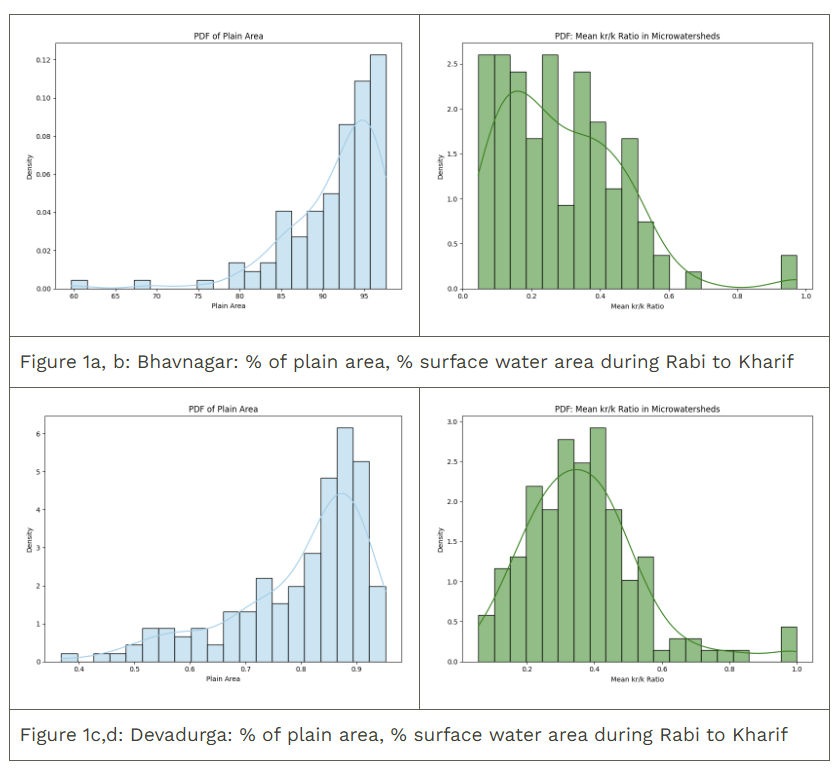

But compare the two locations now based on how their cropping intensity varies with respect to other parameters. Bhavnagar, below, has many micro-watersheds with a positive vertical water balance (defined as Rainfall – Evapotranspiration – Runoff), and cropping intensity varies inversely with water balance (areas with high cropping intensity have a lower water balance). Cropping intensity also varies directly with availability of surface water area, with higher intensity in areas with higher surface water availability. There does not seem to be any specific relationship between cropping intensity and drought frequency. Overall, this seems to be a strong signature of rainfed agriculture with high dependency on surface water. Further analysis on drought sensitivity (a proposed problem for the innovation challenge) can reveal the need for better drought protection infrastructure as well as the scope to expand cropping intensity into the Rabi season.

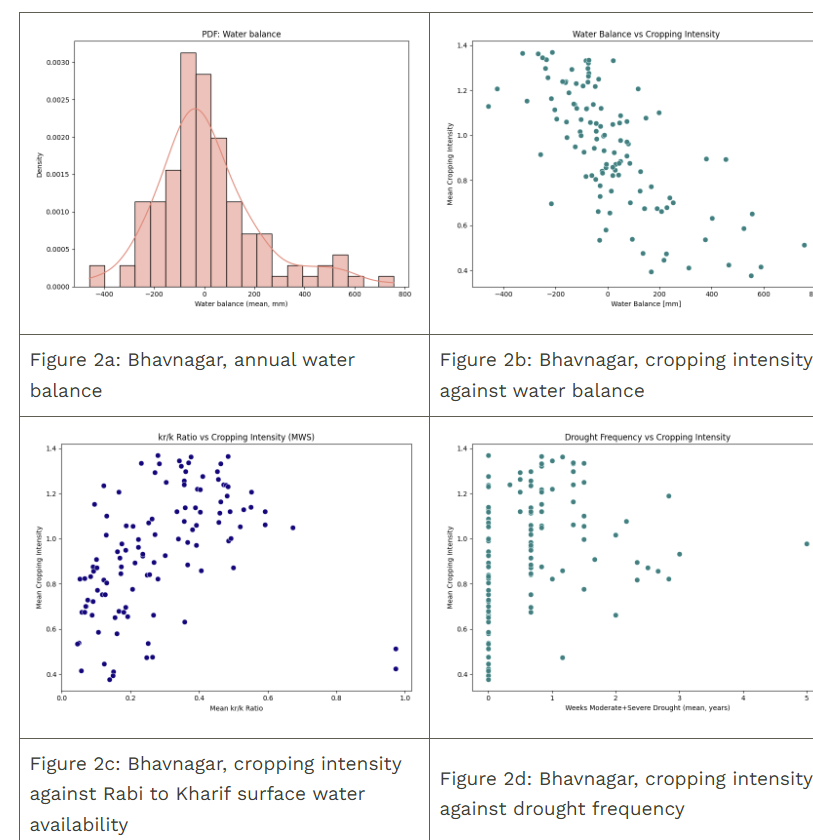

Let us now look at Devadurga, below. First of all, the water balance is negative in all micro-watersheds, showing that the water deficit is either being fulfilled from groundwater or external surface water flows like canal irrigation. Since this distribution is likely to be quite heterogenous, there also does not seem to be any relationship between cropping intensity and water balance. The cropping intensity in general is also quite higher than Bhavnagar. Similarly, there does not seem to be any relationship with surface water availability ratio between Rabi to Kharif either, showing that other irrigation sources offset the reliance on surface water alone. And even though Devadurga seems to be have a higher drought frequency, the cropping intensity does not have any relationship. Overall, this points to a strong signature for irrigated agriculture with potential groundwater stress and low resilience.

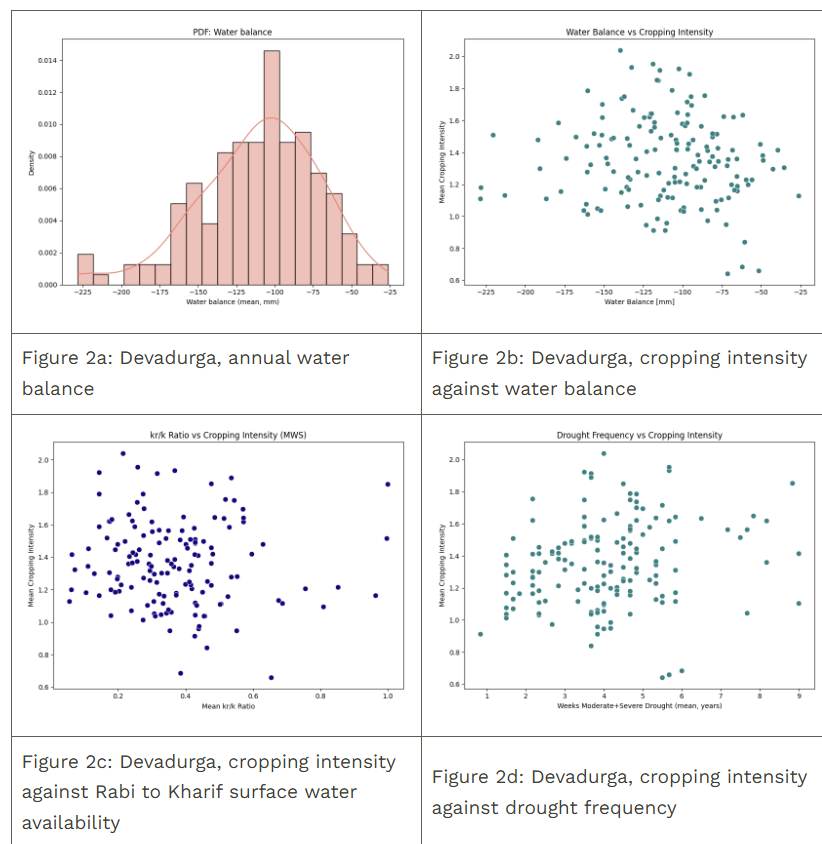

# MWS Interactions

End-to-end workflow:

- Specify an area of interest as a polygon in a GeoJSON
- Find intersectining micro-watersheds, and upstream and downstream micro-watersheds
- Demonstrates use of Google Earth Engine APIs and CoRE stack GEE assets
- Use the APIs to get data of the micro-watersheds
- Flatten into a Pandas dataframe
- Plot graphs embedded into a Folium map

Outputs sample CSVs and charts into the `data/` folder.



In [ ]:
import ee
import folium
from folium.plugins import Fullscreen
import pandas as pd
from shapely.geometry import Point, LineString, Polygon, shape
from io import BytesIO
from ast import literal_eval
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from base64 import b64encode


In [ ]:
#HELPER METHOD TO READ GEOJSON OF AN AREA OF INTEREST AROUND WHICH MICRO-WATERSHEDS CAN BE STUDIED
def parse_geojson(geojson_path):
    """Parse GeoJSON file and extract geometries"""
    with open(geojson_path, 'r') as f:
        geojson_data = json.load(f)

    geometries = []

    # Handle different GeoJSON structures
    if geojson_data['type'] == 'FeatureCollection':
        for feature in geojson_data['features']:
            if 'geometry' in feature and feature['geometry']:
                geometries.append(shape(feature['geometry']))
    elif geojson_data['type'] == 'Feature':
        if 'geometry' in geojson_data and geojson_data['geometry']:
            geometries.append(shape(geojson_data['geometry']))
    elif geojson_data['type'] in ['Point', 'LineString', 'Polygon', 'MultiPoint', 'MultiLineString', 'MultiPolygon']:
        # Direct geometry object
        geometries.append(shape(geojson_data))

    return geometries

In [ ]:
#HELPER METHOD TO CONVERT GEOJSON GEOMETRY FOR OPERATIONS ON GEE
def shapely_to_ee_geometry(geom):
    """Convert Shapely geometry to Earth Engine geometry"""
    if geom.geom_type == 'Point':
        return ee.Geometry.Point([geom.x, geom.y])
    elif geom.geom_type == 'LineString':
#        coords = list(geom.coords)
        coords = [[c[0], c[1]] for c in geom.coords]
        return ee.Geometry.LineString(coords)
    elif geom.geom_type == 'Polygon':
#        coords = list(geom.exterior.coords)
        coords = [[c[0], c[1]] for c in geom.exterior.coords]
        return ee.Geometry.Polygon([coords])
    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom_type}")

In [ ]:
#METHOD TO INTERSECT AREA OF INTEREST WITH MICRO-WATERSHEDS v2 BOUNDARIES ON GEE
def get_intersecting_mws(kml_geometry, mws_polygons):
    """Find MWSes that intersect with the KML geometry"""
    ee_geom = shapely_to_ee_geometry(kml_geometry)
    intersecting = mws_polygons.filterBounds(ee_geom)
    return intersecting

In [ ]:
#METHOD TO FIND UPSTREAM MICRO-WATERSHEDS TO A GIVEN LIST OF MICRO-WATERSHEDS
#USE MICRO-WATERSHED CONNECTIVITY LAYER ON GEE FOR THIS PURPOSE
def get_upstream_mws(mws_ids, connectivity_fc, level=1):
    """Get upstream MWSes for given MWS IDs up to specified level"""
    if level == 0 or not mws_ids:
        return set()

    upstream_ids = set()

    # Find all features where 'uid' is in our mws_ids
    for mws_id in mws_ids:
        mws_features = connectivity_fc.filter(
            ee.Filter.eq('uid', mws_id)
        ).getInfo()['features']

        for feature in mws_features:
            upstream_list = literal_eval(feature['properties'].get('upstream', []))
            if isinstance(upstream_list, list):
                upstream_ids.update(upstream_list)
            elif upstream_list:  # Single value
                upstream_ids.add(upstream_list)

    # Recursively get upstream MWSes for the next level
    if level > 1:
        next_level = get_upstream_mws(upstream_ids, connectivity_fc, level - 1)
        upstream_ids.update(next_level)

    return upstream_ids

In [ ]:
#METHOD TO FIND DOWNSTREAM MICRO-WATERSHEDS TO A GIVEN LIST OF MICRO-WATERSHEDS
#USE MICRO-WATERSHED CONNECTIVITY LAYER ON GEE FOR THIS PURPOSE
def get_downstream_mws(mws_ids, connectivity_fc):
    """Get immediate downstream MWSes for given MWS IDs"""
    downstream_ids = set()

    # Find all features where 'uid' is in our mws_ids
    for mws_id in mws_ids:
        mws_features = connectivity_fc.filter(
            ee.Filter.eq('uid', mws_id)
        ).getInfo()['features']

        for feature in mws_features:
            downstream = feature['properties'].get('downstream')
            if downstream:
                downstream_ids.add(downstream)

    return downstream_ids

In [ ]:
#HELPER METHOD TO GET CENTROID OF A POLYGON
def get_mws_centroid(mws_geometry):
    """Get centroid of an MWS geometry"""
    geom = mws_geometry
    if geom['type'] == 'Polygon':
        coords = geom['coordinates'][0]
    elif geom['type'] == 'MultiPolygon':
        coords = geom['coordinates'][0][0]
    else:
        return None

    # Calculate centroid
    x_coords = [c[0] for c in coords]
    y_coords = [c[1] for c in coords]
    centroid = [np.mean(x_coords), np.mean(y_coords)]
    return centroid

In [ ]:
#METHOD TO FIND TEHSILS THAT A LIST OF MICRO-WATERSHEDS INTERSECT WITH
#USE TEHSIL LAYER ON GEE FOR THIS PURPOSE
def get_intersecting_tehsils(mws_ids, mws_polygons, tehsil_fc):
    """Get tehsils that intersect with the given MWS IDs"""
    # Filter MWS polygons by IDs
    mws_features = mws_polygons.filter(
        ee.Filter.inList('uid', list(mws_ids))
    )

    # Get the union of all MWS geometries
    mws_union = mws_features.geometry().dissolve()

    # Find intersecting tehsils
    intersecting_tehsils = tehsil_fc.filterBounds(mws_union)

    # Get tehsil information
    tehsil_info = intersecting_tehsils.getInfo()

    tehsil_list = []
    for feature in tehsil_info['features']:
        props = feature['properties']
        tehsil_list.append({
            'STATE': props.get('STATE', 'N/A').lower(),
            'District': props.get('District', 'N/A').lower(),
            'TEHSIL': props.get('TEHSIL', 'N/A').lower()
        })

    return tehsil_list

In [ ]:
#PRIMARY METHOD TO BUILD THE MICRO-WATERSHED CONNECTIVITY GRAPH BY CALLING VARIOUS HELPER METHODS
#ALSO COMPUTE CENTROIDS OF THE MICRO-WATERSHEDS
def build_mws_network(geojson_path):
    """Main function to process GeoJSON and plot MWS network"""

    # Parse KML
    print("Parsing GeoJSON file...")
    geometries = parse_geojson(geojson_path)

    if not geometries:
        raise ValueError("No geometries found in GeoJSON file")

    # Load datasets
    print("Loading GEE datasets...")
    mws_connectivity = ee.FeatureCollection(
        "projects/corestack-datasets/assets/datasets/India_mws_connectivity"
    )
    mws_polygons = ee.FeatureCollection(
        "projects/corestack-datasets/assets/datasets/India_mws_uid_area_gt_500"
    )
    tehsil_fc = ee.FeatureCollection(
        "projects/ext-datasets/assets/datasets/SOI_tehsil"
    )

    # Get intersecting MWSes
    print("Finding intersecting MWSes...")
    all_intersecting_ids = set()

    for geom in geometries:
        intersecting = get_intersecting_mws(geom, mws_polygons)
        intersecting_info = intersecting.getInfo()

        for feature in intersecting_info['features']:
            uid = feature['properties'].get('uid')
            if uid:
                all_intersecting_ids.add(uid)

    print(f"Found {len(all_intersecting_ids)} intersecting MWSes: {all_intersecting_ids}")

    # Get upstream and downstream MWSes
    print("Finding upstream MWSes (3 levels)...")
    upstream_level1 = get_upstream_mws(all_intersecting_ids, mws_connectivity, level=1)
    upstream_level2 = get_upstream_mws(upstream_level1, mws_connectivity, level=1)
    upstream_level3 = get_upstream_mws(upstream_level2, mws_connectivity, level=1)

    print("Finding downstream MWSes (1 level)...")
    downstream_level1 = get_downstream_mws(all_intersecting_ids, mws_connectivity)

    # Combine all MWS IDs
    all_mws_ids = all_intersecting_ids.union(upstream_level1).union(upstream_level2).union(upstream_level3).union(downstream_level1)

    print(f"Total MWSes: {len(all_mws_ids)}")
    print(f"  - Intersecting: {len(all_intersecting_ids)} - {all_intersecting_ids}")
    print(f"  - Upstream Level 1: {len(upstream_level1)} - {upstream_level1}")
    print(f"  - Upstream Level 2: {len(upstream_level2)} - {upstream_level2}")
    print(f"  - Upstream Level 3: {len(upstream_level3)} - {upstream_level3}")
    print(f"  - Downstream: {len(downstream_level1)} - {downstream_level1}")

    # Get intersecting tehsils
    print("Finding intersecting tehsils...")
    tehsil_list = get_intersecting_tehsils(all_mws_ids, mws_polygons, tehsil_fc)

    print(f"\nIntersecting Tehsils ({len(tehsil_list)}):")
    for tehsil in tehsil_list:
        print(f"  - {tehsil['TEHSIL']}, {tehsil['District']}, {tehsil['STATE']}")

    # Get MWS features for plotting
    print("\nFetching MWS geometries...")
    mws_features_list = mws_polygons.filter(
        ee.Filter.inList('uid', list(all_mws_ids))
    ).getInfo()['features']

    # Create a map of uid to centroid and level
    mws_data = {}
    for feature in mws_features_list:
        uid = feature['properties']['uid']
        centroid = get_mws_centroid(feature['geometry'])

        # Determine level
        if uid in all_intersecting_ids:
            level = 'intersecting'
        elif uid in upstream_level1:
            level = 'upstream_l1'
        elif uid in upstream_level2:
            level = 'upstream_l2'
        elif uid in upstream_level3:
            level = 'upstream_l3'
        elif uid in downstream_level1:
            level = 'downstream_l1'
        else:
            level = 'other'

        mws_data[uid] = {
            'centroid': centroid,
            'level': level,
            'geometry': feature['geometry']
        }

    return all_mws_ids, tehsil_list, mws_data, geometries, mws_connectivity

In [ ]:
#PRIMARY FUNCTION TO PLOT THE MICRO-WATERSHEDS AND TIME SERIES DATA ON A MAP
def plot_mws_network(tehsils_df, all_mws_ids, tehsil_list, mws_data, geometries, mws_connectivity, output_html='data/mws_network.html'):
    # Create map centered on the KML area
    first_geom = geometries[0]
    center_coords = list(first_geom.centroid.coords)[0]
    m = folium.Map(location=[center_coords[1], center_coords[0]], zoom_start=12)

    folium.TileLayer(
        tiles='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
        attr='Google',
        name='Google Satellite',
        overlay=True,
        control=True
    ).add_to(m)
    folium.LayerControl().add_to(m)

    Fullscreen(
        position="topright",
        title="Expand me",
        title_cancel="Exit me",
        force_separate_button=True,
    ).add_to(m)

    # Color scheme for different levels
    colors = {
        'intersecting': '#FF0000',    # Red
        'upstream_l1': '#FFA500',     # Orange
        'upstream_l2': '#FFFF00',     # Yellow
        'upstream_l3': '#FFF000',     # XXX
        'downstream_l1': '#0000FF',   # Blue
        'other': '#808080'            # Gray
    }

    # Plot MWS polygons
    print("Plotting MWS polygons...")
    for uid, data in mws_data.items():
        geom = data['geometry']
        level = data['level']
        color = colors.get(level, '#808080')

        # Convert geometry to GeoJSON format for Folium
        if geom['type'] == 'Polygon':
            coords = [[[c[1], c[0]] for c in geom['coordinates'][0]]]
        elif geom['type'] == 'MultiPolygon':
            coords = [[[[c[1], c[0]] for c in poly[0]] for poly in geom['coordinates']]]
        else:
            continue

        row_df = tehsils_df.query(f"uid == '{uid}'")
        if row_df.empty:
            continue  # Skip if no matching row found
        row = row_df.iloc[0]  # Get first row as a Series

        # Set font sizes globally for all plots
        plt.rcParams.update({'font.size': 8, 'axes.titlesize': 8, 'axes.labelsize': 8,
                            'xtick.labelsize': 8, 'ytick.labelsize': 8, 'legend.fontsize': 8})

        # Prepare terrain values and labels
        area_in_ha = (float)(row.get("area_in_ha"))
        terrain_vals = []
        terrain_labels = []
        for key in ['plain_area', 'slopy_area', 'hill_slope', 'valley_are', 'ridge_area']:
            val = row.get(key)
            # Check if value is not null and > 0
            if pd.notna(val) and float(val) > 0:
                terrain_vals.append(float(val) * area_in_ha / 100)
                terrain_labels.append(key.replace('_', ' ').capitalize())

        if terrain_vals and sum(terrain_vals) > 0:
            plt.figure(figsize=(2.5, 2))
            plt.bar(terrain_labels, terrain_vals)
            plt.ylabel('Area in ha', fontsize=8)
            plt.xticks(rotation=45, ha='right', fontsize=8)
            plt.yticks(fontsize=8)
            plt.tight_layout()
            pie_path = f"data/pie_{uid}.png"
            plt.savefig(pie_path, dpi=200, bbox_inches='tight')
            plt.close()

            # Prepare HTML for terrain chart image
            with open(pie_path, 'rb') as imgf:
                pie_img_b64 = b64encode(imgf.read()).decode('utf-8')
                pie_html = f'<img src="data:image/png;base64,{pie_img_b64}" style="width:175px; height:auto;"/>'
        else:
            pie_html = ''

        # Prepare tree cover loss values and labels
        treeloss_vals = []
        treeloss_labels = []
        for key in ['forest_to_barren', 'forest_to_builtu', 'forest_to_farm', 'forest_to_scrub']:
            val = row.get(key)
            # Check if value is not null and > 0
            if pd.notna(val) and float(val) > 0:
                treeloss_vals.append(float(val))
                treeloss_labels.append(key.replace('_', ' ').capitalize())

        if treeloss_vals and sum(treeloss_vals) > 0:
            plt.figure(figsize=(2.5, 2))
            plt.bar(treeloss_labels, treeloss_vals)
            plt.ylabel('Area in ha', fontsize=8)
            plt.xticks(rotation=45, ha='right', fontsize=8)
            plt.yticks(fontsize=8)
            plt.title('Tree cover loss', fontsize=8)
            plt.tight_layout()
            tree_path = f"data/tree_{uid}.png"
            plt.savefig(tree_path, dpi=100, bbox_inches='tight')
            plt.close()

            # Prepare HTML for terrain chart image
            with open(tree_path, 'rb') as imgf:
                tree_img_b64 = b64encode(imgf.read()).decode('utf-8')
                tree_html = f'<img src="data:image/png;base64,{tree_img_b64}" style="width:175px; height:auto;"/>'
        else:
            tree_html = ''

        # Generate time-series plot for water availability
        sw_ts_html = ''
        sw_k_list = row.get('sw_k', [])
        sw_r_list = row.get('sw_r', [])
        sw_z_list = row.get('sw_z', [])

        if sw_k_list or sw_r_list or sw_z_list:
            # Ensure all lists have the same length (pad with NaN if needed)
            max_len = max(len(sw_k_list) if sw_k_list else 0,
                         len(sw_r_list) if sw_r_list else 0,
                         len(sw_z_list) if sw_z_list else 0)
            if max_len > 0:
                # Years for x-axis (assuming data starts from 2017 and is consecutive)
                years = list(range(2017, 2017 + max_len))

                if len(sw_k_list) < max_len:
                    sw_k_list = sw_k_list + [np.nan] * (max_len - len(sw_k_list))
                if len(sw_r_list) < max_len:
                    sw_r_list = sw_r_list + [np.nan] * (max_len - len(sw_r_list))
                if len(sw_z_list) < max_len:
                    sw_z_list = sw_z_list + [np.nan] * (max_len - len(sw_z_list))

                plt.figure(figsize=(2.5, 2))
                plt.plot(years, sw_k_list, marker='o', label='Kharif (sw_k)', linewidth=1.5, markersize=3)
                plt.plot(years, sw_r_list, marker='s', label='Kharif+Rabi (sw_r)', linewidth=1.5, markersize=3)
                plt.plot(years, sw_z_list, marker='^', label='Kharif+Rabi+Zaid (sw_z)', linewidth=1.5, markersize=3)
                plt.xlabel('Year', fontsize=8)
                plt.ylabel('Water Availability (% of area)', fontsize=8)
                plt.title('Surface Water Availability Time-Series', fontsize=8)
                plt.legend(prop={'size': 8}, loc='best')
                plt.xticks(fontsize=8)
                plt.yticks(fontsize=8)
                plt.grid(True, alpha=0.3)
                plt.tight_layout()

                sw_ts_path = f"data/sw_ts_{uid}.png"
                plt.savefig(sw_ts_path, dpi=100, bbox_inches='tight')
                plt.close()

                # Prepare HTML for time-series chart image
                with open(sw_ts_path, 'rb') as imgf:
                    sw_ts_img_b64 = b64encode(imgf.read()).decode('utf-8')
                    sw_ts_html = f'<img src="data:image/png;base64,{sw_ts_img_b64}" style="width:175px; height:auto;"/>'

        # Generate time-series plot for hydrological data
        # Create figure with two y-axes
        fig, ax1 = plt.subplots(figsize=(7, 3.5))

        # Create second y-axis that shares the same x-axis
        ax2 = ax1.twinx()

        hydro_dates = list(row.get('hydro_dates')) if row.get('hydro_dates') is not None else []
        hydro_rainfall = row.get('hydro_rainfall') if row.get('hydro_rainfall') is not None else np.array([])
        hydro_et = row.get('hydro_et') if row.get('hydro_et') is not None else np.array([])
        hydro_runoff = row.get('hydro_runoff') if row.get('hydro_runoff') is not None else np.array([])
        hydro_waterbalance = row.get('hydro_waterbalance') if row.get('hydro_waterbalance') is not None else np.array([])

        # Plot precipitation as bars coming from top (on ax2, inverted)
        ax2.bar(hydro_dates, hydro_rainfall, width=5, color='steelblue', alpha=0.6, label='Rainfall')
        ax2.set_ylabel('Rainfall (mm)', fontsize=8, color='steelblue')
        ax2.tick_params(axis='y', labelcolor='steelblue')
        ax2.invert_yaxis()  # Invert so rain comes from top
        ax2.set_ylim(max(hydro_rainfall) * 1.25, 0)  # Set limits with padding

        # Plot stacked ET and runoff (on ax1)
#        ax1.bar(hydro_dates, hydro_et, width=5, color='orange', alpha=0.7, label='ET')
#        ax1.bar(hydro_dates, hydro_runoff, width=5, bottom=hydro_et, color='brown', alpha=0.7, label='Runoff')
        ax1.bar(hydro_dates, hydro_runoff, width=5, color='brown', alpha=0.7, label='Runoff')

        # Plot water balance as a line (on ax1)
#        ax1.plot(hydro_dates, hydro_waterbalance, color='green', linewidth=1, marker='o',
#                markersize=1, label='Water Balance', zorder=5)

        # Add horizontal line at y=0 for reference
        ax1.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

        # Format x-axis
        ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

        # Labels and title
        ax1.set_xlabel('Date', fontsize=8)
        ax1.set_ylabel('ET, Runoff, Water Balance (mm)', fontsize=8)
        ax1.set_title('Water Balance Analysis', fontsize=8)

        # Legends
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

        # Grid
        ax1.grid(True, alpha=0.3, axis='y')

        # Tight layout
        plt.tight_layout()

        hydro_ts_path = f"data/hydro_ts_{uid}.png"
        plt.savefig(hydro_ts_path, dpi=100, bbox_inches='tight')
        plt.close()

        # Prepare HTML for time-series chart image
        with open(hydro_ts_path, 'rb') as imgf:
            hydro_ts_img_b64 = b64encode(imgf.read()).decode('utf-8')
            hydro_ts_html = f'<img src="data:image/png;base64,{hydro_ts_img_b64}" style="width:400px; height:auto;"/>'

        # Prepare the popup HTML with side-by-side layout
        charts_html = ''
        if pie_html or tree_html or sw_ts_html:
            charts_html = '<div style="display:flex; flex-direction:row; width:100%; min-width:500px;"><table border=0><tr>'
#            if pie_html:
#                charts_html += f'<div style="flex:1; text-align:center;"><b style="font-size:11px;">Terrain Distribution</b>{pie_html}</div>'
            if sw_ts_html:
                charts_html += f'<td><div style="flex:1; text-align:left;">{sw_ts_html}</div></td>'
            if tree_html:
                charts_html += f'<td><div style="flex:1; text-align:left;">{tree_html}</div></td>'
            if hydro_ts_html:
                charts_html += f'</tr><tr><td colspan=2><div style="flex:1; text-align:left;">{hydro_ts_html}</div></td></tr><tr>'

            charts_html += '</tr></table></div>'

        popup_html = (
            f"MWS UID: {uid}<br>"
            f"Level: {level}<br>"
            f"Area (ha): {row.get('area_in_ha', '?')}"
            f"{charts_html}"
            f"<a href=\"{row.get('url')}\">MWS report</a>"
        )

        folium.Polygon(
            locations=coords[0] if geom['type'] == 'Polygon' else coords[0][0],
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.3,
            weight=2,
            popup = folium.Popup(popup_html, max_width=400)
        ).add_to(m)

    # Plot connections with arrows
    print("Plotting connections...")
    for uid in all_mws_ids:
        if uid not in mws_data:
            continue

        # Get connectivity info
        conn_features = mws_connectivity.filter(
            ee.Filter.eq('uid', uid)
        ).getInfo()['features']

        for feature in conn_features:
            props = feature['properties']
            downstream = props.get('downstream')

            if downstream and downstream in mws_data:
                from_centroid = mws_data[uid]['centroid']
                to_centroid = mws_data[downstream]['centroid']

                if from_centroid and to_centroid:
                    # Draw arrow
                    start = [from_centroid[1], from_centroid[0]]
                    end = [to_centroid[1], to_centroid[0]]

                    folium.PolyLine(
                        locations=[start, end],
                        color='#000000',
                        weight=2,
                        opacity=0.6,
                        popup=f"{uid} → {downstream}"
                    ).add_to(m)

                    # Add arrowhead
                    folium.RegularPolygonMarker(
                        location=end,
                        fill_color='#000000',
                        color='#000000',
                        number_of_sides=3,
                        radius=6,
                        rotation=0
                    ).add_to(m)

    # Add legend
    legend_html = '''
    <div style="position: fixed;
                bottom: 50px; right: 50px; width: 100px; height: auto;
                background-color: white; z-index:9999; font-size:10px;
                border:2px solid grey; padding: 2px">
    <p style="margin:0"><b>MWS Levels</b></p>
    <p style="margin:2px 0"><span style="color:#FF0000">█</span> Intersecting</p>
    <p style="margin:2px 0"><span style="color:#FFA500">█</span> Upstream L1</p>
    <p style="margin:2px 0"><span style="color:#FFFF00">█</span> Upstream L2</p>
    <p style="margin:2px 0"><span style="color:#FFFF00">█</span> Upstream L3</p>
    <p style="margin:2px 0"><span style="color:#0000FF">█</span> Downstream</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    # Save map
    m.save(output_html)
    print(f"\nMap saved to {output_html}")

In [ ]:
geojson_file = "/content/data/Sunderpahari.geojson"

In [ ]:
ee.Authenticate()

In [ ]:
ee.Initialize(project="ee-ankitkumar")

In [ ]:
mwses, tehsils, mws_data, geometries, mws_connectivity = build_mws_network(geojson_file)

In [ ]:
print(mwses)

In [ ]:
print(tehsils)

In [ ]:
tehsils_df = None
mws_params = [
    "change_detection_deforestation",
    "change_detection_afforestation",
    "hydrological_annual",
    "surfaceWaterBodies_annual",
    "terrain",
    "terrain_lulc_plain",
    "terrain_lulc_slope"
    ]

In [ ]:
active_tehsils = get_active_tehsils()
for tehsil in tehsils:
    if tehsil in active_tehsils:
        print(f"found tehsil {tehsil}")
#            tehsil_obj = get_tehsil_data_from_layers(tehsil["STATE"], tehsil["District"], tehsil["TEHSIL"])
        tehsil_obj = get_tehsil_data_from_api(tehsil["STATE"], tehsil["District"], tehsil["TEHSIL"], mws_params)
        get_hydrological_data_from_api(tehsil_obj, mwses)
        df = build_df(tehsil_obj, mwses)
        if tehsils_df is None:
            tehsils_df = df
        else:
            tehsils_df = pd.concat([tehsils_df, df], ignore_index=True).drop_duplicates(subset=['uid'])
    else:
        print(f"not found tehsil {tehsil}")

In [ ]:
plot_mws_network(tehsils_df, mwses, tehsils, mws_data, geometries, mws_connectivity)